In [1]:
!pip install tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow version:", tf.__version__)

# Check GPU
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
QUICK_RUN = True

if QUICK_RUN:
    TRAIN_SIZE = 10000
    TEST_SIZE = 2000
    EPOCHS = 3
else:
    TRAIN_SIZE = 50000
    TEST_SIZE = 10000
    EPOCHS = 10

BATCH_SIZE = 32
NUM_CLASSES = 10
IMG_SIZE = 32

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("Original training shape:", x_train.shape)
print("Original testing shape:", x_test.shape)

# Convert labels from (n,1) to (n,)
y_train = y_train.flatten()
y_test = y_test.flatten()

# Use subset if QUICK_RUN
x_train = x_train[:TRAIN_SIZE]
y_train = y_train[:TRAIN_SIZE]

x_test = x_test[:TEST_SIZE]
y_test = y_test[:TEST_SIZE]

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1830s 11us/step
Original training shape: (50000, 32, 32, 3)
Original testing shape: (10000, 32, 32, 3)
Training data: (10000, 32, 32, 3)
Testing data: (2000, 32, 32, 3)


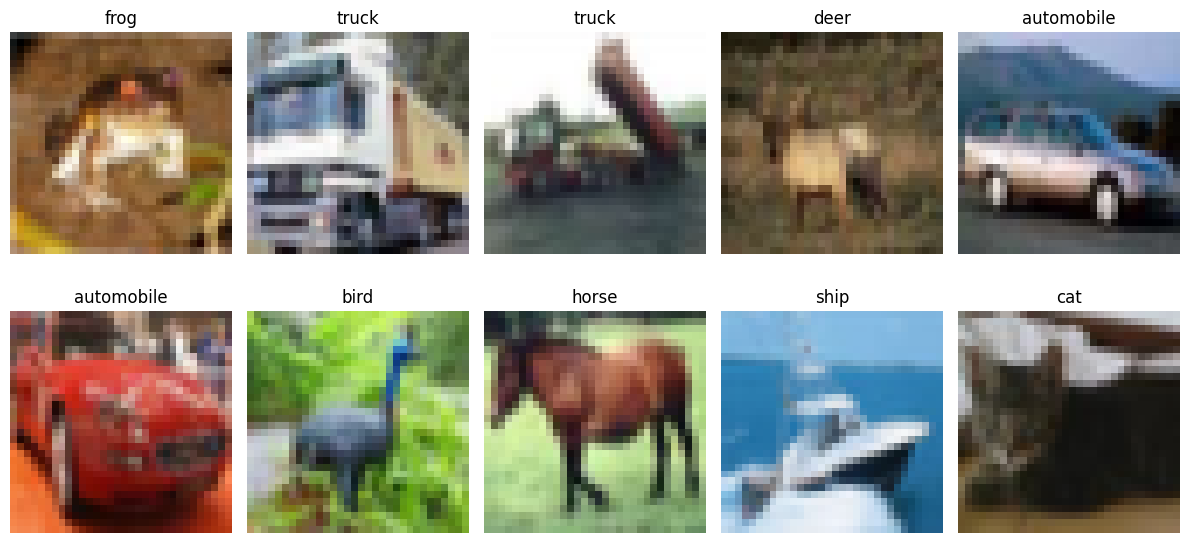

In [4]:
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(CLASS_NAMES[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))

train_ds = train_ds.shuffle(10000, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [6]:
def build_lenet5():

    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(6, (5, 5), activation="tanh", padding="same"),
        layers.AveragePooling2D(pool_size=(2, 2)),

        layers.Conv2D(16, (5, 5), activation="tanh"),
        layers.AveragePooling2D(pool_size=(2, 2)),

        layers.Flatten(),

        layers.Dense(120, activation="tanh"),
        layers.Dense(84, activation="tanh"),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    return model


lenet = build_lenet5()
lenet.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 16, 16, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 6, 6, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        69,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,126 (324.71 KB)

 Trainable params: 83,126 (324.71 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
def build_alexnet():

    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(192, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(384, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(256, (3, 3), padding="same", activation="relu"),

        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(512, activation="relu"),
        layers.Dropout(0.5),

        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),

        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    return model


alexnet = build_alexnet()
alexnet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 192)    │       110,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 192)    │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 384)      │       663,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,484,170 (17.11 MB)

 Trainable params: 4,483,658 (17.10 MB)

 Non-trainable params: 512 (2.00 KB)

In [8]:
def build_vgg16_scratch():

    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        # Block 1
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        # Block 2
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        # Block 3
        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        # Classification
        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    return model


vgg16_scratch = build_vgg16_scratch()
vgg16_scratch.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,248,202 (12.39 MB)

 Trainable params: 3,248,202 (12.39 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
def inception_module(x, filters):

    f1, f3_reduce, f3, f5_reduce, f5, pool_proj = filters

    # 1x1 convolution
    branch1 = layers.Conv2D(
        f1, (1, 1), padding="same", activation="relu"
    )(x)

    # 1x1 -> 3x3
    branch2 = layers.Conv2D(
        f3_reduce, (1, 1), padding="same", activation="relu"
    )(x)

    branch2 = layers.Conv2D(
        f3, (3, 3), padding="same", activation="relu"
    )(branch2)

    # 1x1 -> 5x5
    branch3 = layers.Conv2D(
        f5_reduce, (1, 1), padding="same", activation="relu"
    )(x)

    branch3 = layers.Conv2D(
        f5, (5, 5), padding="same", activation="relu"
    )(branch3)

    # Pooling -> 1x1
    branch4 = layers.MaxPooling2D(
        (3, 3), strides=(1, 1), padding="same"
    )(x)

    branch4 = layers.Conv2D(
        pool_proj, (1, 1), padding="same", activation="relu"
    )(branch4)

    return layers.Concatenate()([
        branch1,
        branch2,
        branch3,
        branch4
    ])


def build_googlenet():

    inputs = layers.Input(shape=(32, 32, 3))

    x = layers.Conv2D(
        64, (3, 3), padding="same", activation="relu"
    )(inputs)

    x = layers.MaxPooling2D((2, 2))(x)

    x = inception_module(
        x,
        (32, 48, 64, 8, 16, 16)
    )

    x = inception_module(
        x,
        (64, 64, 96, 16, 32, 32)
    )

    x = layers.MaxPooling2D((2, 2))(x)

    x = inception_module(
        x,
        (96, 64, 128, 16, 32, 32)
    )

    x = inception_module(
        x,
        (128, 96, 192, 32, 64, 64)
    )

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    return models.Model(inputs, outputs)


googlenet = build_googlenet()
googlenet.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 32, 32,    │      1,792 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 16, 16,    │          0 │ conv2d_13[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 16, 16,    │      3,120 │ max_pooling2d_6[… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 16, 16, 8) │        520 │ max_pooling2d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 16, 16,    │          0 │ max_pooling2d_6[… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 16, 16,    │      2,080 │ max_pooling2d_6[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 16, 16,    │     27,712 │ conv2d_15[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 16, 16,    │      3,216 │ conv2d_17[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 16, 16,    │      1,040 │ max_pooling2d_7[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_14[0][0],  │
│ (Concatenate)       │ 128)              │            │ conv2d_16[0][0],  │
│                     │                   │            │ conv2d_18[0][0],  │
│                     │                   │            │ conv2d_19[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 16, 16,    │      8,256 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 16, 16,    │      2,064 │ concatenate[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 16, 16,    │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 16, 16,    │      8,256 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 16, 16,    │     55,392 │ conv2d_21[0][0]   │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 578,210 (2.21 MB)

 Trainable params: 578,210 (2.21 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
def build_resnet50():

    base = keras.applications.ResNet50(
        include_top=False,
        weights=None,
        input_shape=(32, 32, 3)
    )

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    return models.Model(base.input, output)


resnet50 = build_resnet50()
resnet50.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 24,061,706 (91.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [11]:
def train_model(model, name, epochs=EPOCHS, learning_rate=0.001):

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=test_ds,
        epochs=epochs,
        verbose=1
    )

    training_time = time.time() - start_time

    print(f"\n{name} training time: {training_time:.2f} seconds")

    return history, training_time

In [12]:
results = {}
histories = {}
trained_models = {}

In [13]:
history, train_time = train_model(
    lenet,
    "LeNet-5"
)

histories["LeNet-5"] = history
trained_models["LeNet-5"] = lenet
results["LeNet-5"] = train_time

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.3157 - loss: 1.9114 - val_accuracy: 0.3665 - val_loss: 1.8151
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3855 - loss: 1.7531 - val_accuracy: 0.3815 - val_loss: 1.7728
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4098 - loss: 1.6865 - val_accuracy: 0.3825 - val_loss: 1.7174

LeNet-5 training time: 18.87 seconds


In [14]:
history, train_time = train_model(
    alexnet,
    "AlexNet"
)

histories["AlexNet"] = history
trained_models["AlexNet"] = alexnet
results["AlexNet"] = train_time

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.2596 - loss: 1.9780 - val_accuracy: 0.1390 - val_loss: 2.6847
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3995 - loss: 1.6354 - val_accuracy: 0.3520 - val_loss: 1.8537
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4686 - loss: 1.4708 - val_accuracy: 0.4340 - val_loss: 1.4827

AlexNet training time: 25.45 seconds


In [15]:
history, train_time = train_model(
    vgg16_scratch,
    "VGG16"
)

histories["VGG16"] = history
trained_models["VGG16"] = vgg16_scratch
results["VGG16"] = train_time

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.2224 - loss: 2.0574 - val_accuracy: 0.3000 - val_loss: 1.8456
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3611 - loss: 1.7030 - val_accuracy: 0.4300 - val_loss: 1.5847
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4502 - loss: 1.4823 - val_accuracy: 0.5185 - val_loss: 1.3314

VGG16 training time: 19.59 seconds


In [16]:
history, train_time = train_model(
    googlenet,
    "GoogleNet"
)

histories["GoogleNet"] = history
trained_models["GoogleNet"] = googlenet
results["GoogleNet"] = train_time

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 55ms/step - accuracy: 0.2087 - loss: 2.0537 - val_accuracy: 0.3020 - val_loss: 1.8534
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3237 - loss: 1.7683 - val_accuracy: 0.4065 - val_loss: 1.5845
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4092 - loss: 1.5859 - val_accuracy: 0.4610 - val_loss: 1.4744

GoogleNet training time: 41.79 seconds


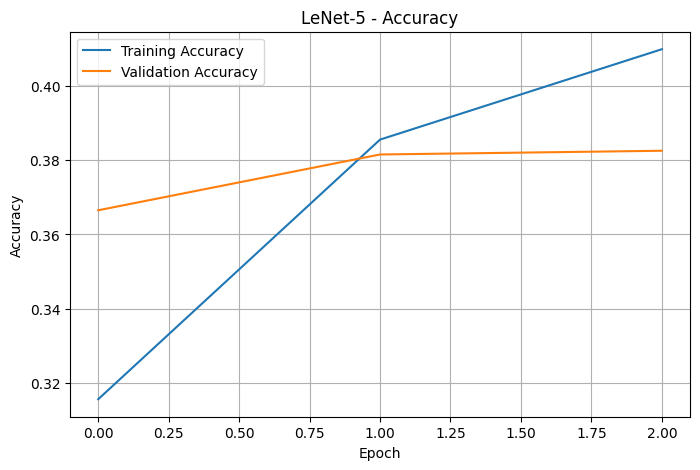

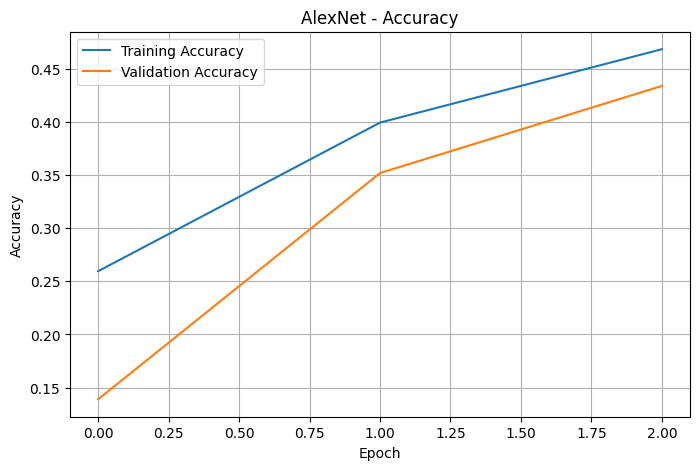

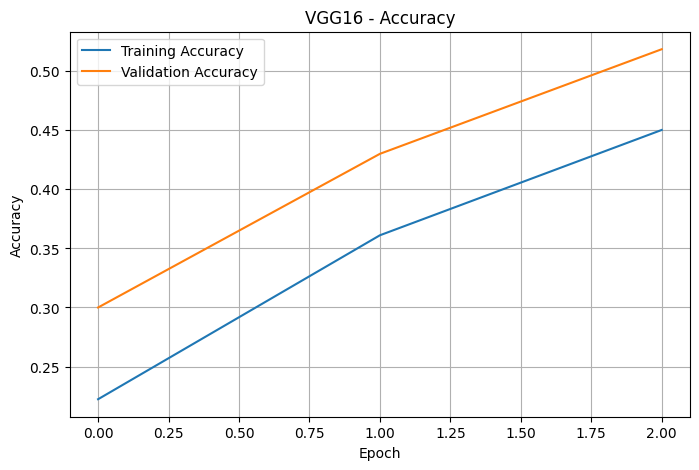

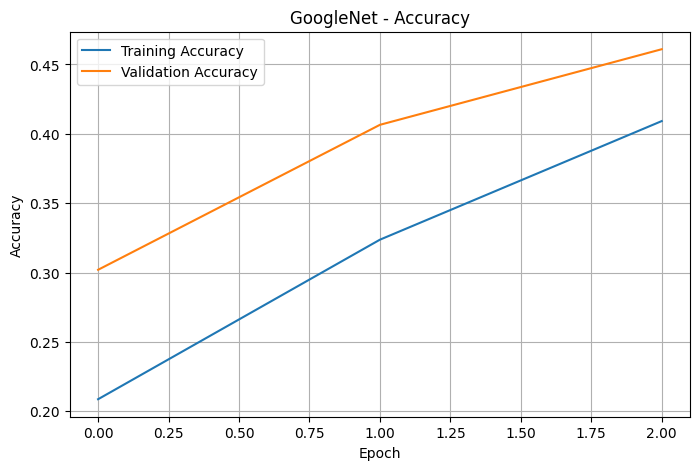

In [17]:
def plot_accuracy(history, name):

    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        history.history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.title(f"{name} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


for name, history in histories.items():
    plot_accuracy(history, name)

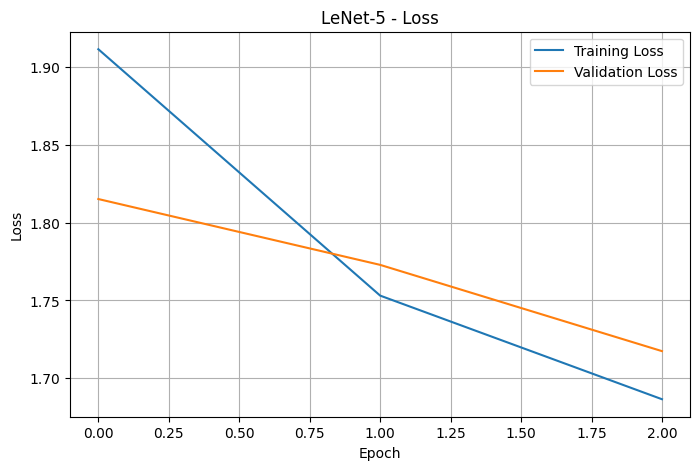

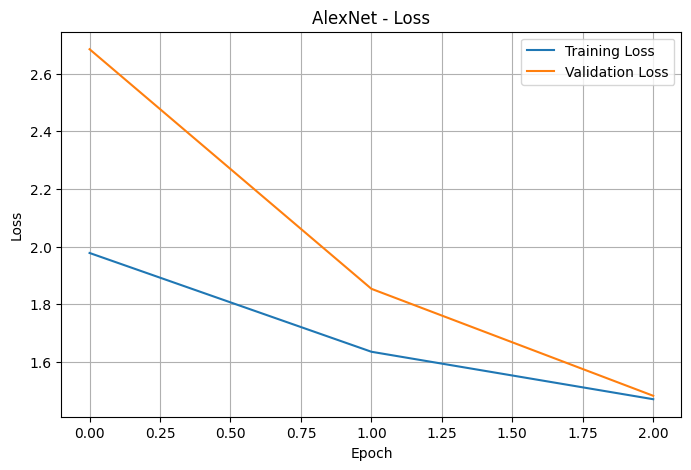

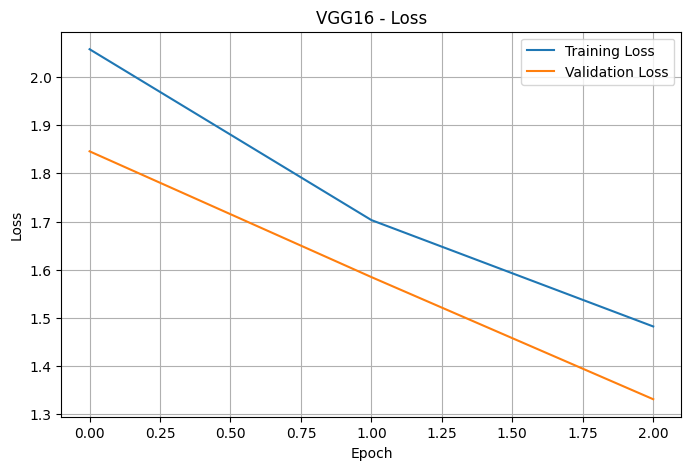

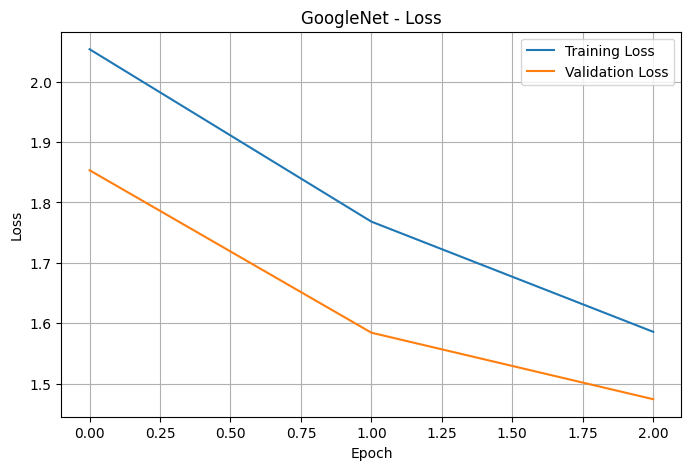

In [18]:
def plot_loss(history, name):

    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["loss"],
        label="Training Loss"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.title(f"{name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


for name, history in histories.items():
    plot_loss(history, name)

In [19]:
def evaluate_model(model, name):

    loss, accuracy = model.evaluate(
        test_ds,
        verbose=0
    )

    y_prob = model.predict(
        x_test,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    y_pred = np.argmax(y_prob, axis=1)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Parameters": model.count_params(),
        "Training Time (s)": results[name]
    }

In [20]:
evaluation_results = []

for name, model in trained_models.items():

    result = evaluate_model(
        model,
        name
    )

    evaluation_results.append(result)

results_df = pd.DataFrame(evaluation_results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,Parameters,Training Time (s)
0,LeNet-5,0.3825,0.389973,0.3825,0.364566,83126,18.874114
1,AlexNet,0.4340,0.499519,0.4340,0.427934,4484170,25.447284
2,VGG16,0.5185,0.528900,0.5185,0.508849,3248202,19.593952
3,GoogleNet,0.4610,0.472594,0.4610,0.438888,578210,41.793231


In [21]:
for name, model in trained_models.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    predictions = model.predict(
        x_test,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    y_pred = np.argmax(predictions, axis=1)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=CLASS_NAMES,
            zero_division=0
        )
    )


LeNet-5
              precision    recall  f1-score   support

    airplane       0.50      0.27      0.35       196
  automobile       0.45      0.61      0.52       198
        bird       0.22      0.21      0.21       195
         cat       0.28      0.21      0.24       199
        deer       0.27      0.26      0.26       198
         dog       0.50      0.14      0.21       185
        frog       0.38      0.68      0.49       216
       horse       0.38      0.53      0.44       193
        ship       0.47      0.53      0.50       217
       truck       0.45      0.34      0.39       203

    accuracy                           0.38      2000
   macro avg       0.39      0.38      0.36      2000
weighted avg       0.39      0.38      0.36      2000


AlexNet
              precision    recall  f1-score   support

    airplane       0.41      0.56      0.47       196
  automobile       0.81      0.42      0.55       198
        bird       0.38      0.25      0.30       195
      

Best model: VGG16


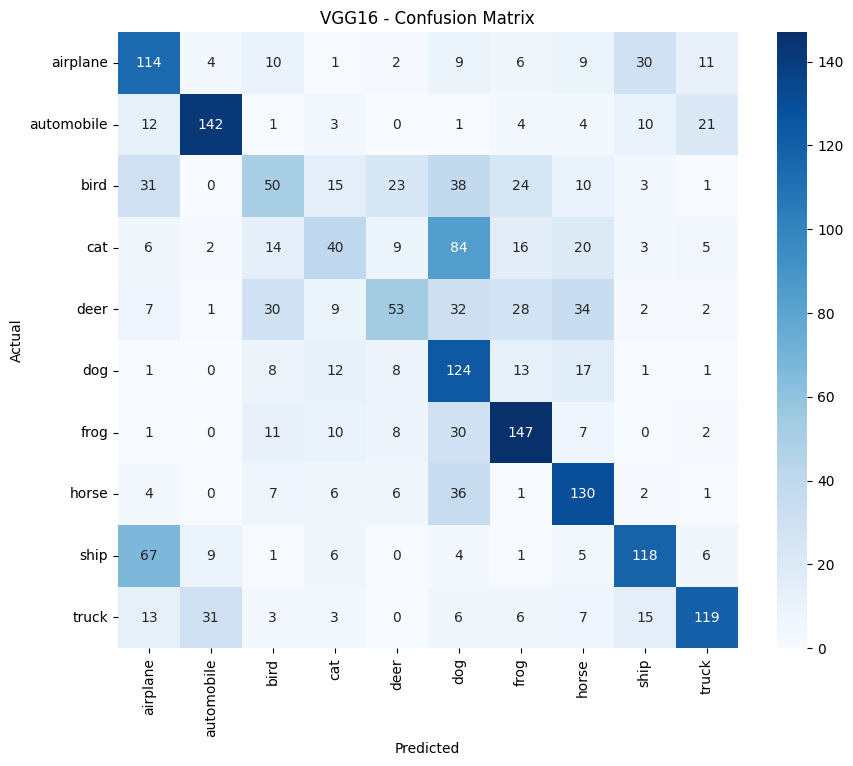

In [22]:
def plot_confusion_matrix(model, name):

    predictions = model.predict(
        x_test,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    y_pred = np.argmax(predictions, axis=1)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        cmap="Blues"
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# Plot for the best model
best_model_name = results_df.loc[
    results_df["Accuracy"].idxmax(),
    "Model"
]

print("Best model:", best_model_name)

plot_confusion_matrix(
    trained_models[best_model_name],
    best_model_name
)

In [23]:
comparison_table = results_df[
    [
        "Model",
        "Parameters",
        "Accuracy",
        "Training Time (s)"
    ]
].copy()

comparison_table["Accuracy (%)"] = (
    comparison_table["Accuracy"] * 100
).round(2)

comparison_table = comparison_table.drop(
    columns=["Accuracy"]
)

comparison_table

,Model,Parameters,Training Time (s),Accuracy (%)
0,LeNet-5,83126,18.874114,38.25
1,AlexNet,4484170,25.447284,43.40
2,VGG16,3248202,19.593952,51.85
3,GoogleNet,578210,41.793231,46.10


In [24]:
TRANSFER_SIZE = 224
BATCH_SIZE = 8

def preprocess_transfer(image, label):
    image = tf.image.resize(image, (224, 224))
    return image, label


transfer_train_ds = (
    tf.data.Dataset
    .from_tensor_slices((x_train, y_train))
    .shuffle(5000)
    .map(
        preprocess_transfer,
        num_parallel_calls=1
    )
    .batch(BATCH_SIZE)
    .prefetch(1)
)

transfer_test_ds = (
    tf.data.Dataset
    .from_tensor_slices((x_test, y_test))
    .map(
        preprocess_transfer,
        num_parallel_calls=1
    )
    .batch(BATCH_SIZE)
    .prefetch(1)
)

print("Transfer-learning datasets ready.")

Transfer-learning datasets ready.


In [25]:
from tensorflow import keras
from tensorflow.keras import layers, models

base_vgg = keras.applications.VGG16(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze convolutional base
base_vgg.trainable = False

x = base_vgg.output

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dropout(0.5)(x)

output = layers.Dense(
    10,
    activation="softmax"
)(x)

transfer_vgg = models.Model(
    inputs=base_vgg.input,
    outputs=output
)

transfer_vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [26]:
transfer_vgg.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [27]:
import time

start_time = time.time()

transfer_history = transfer_vgg.fit(
    transfer_train_ds,
    validation_data=transfer_test_ds,
    epochs=2,
    verbose=1
)

transfer_training_time = time.time() - start_time

print(
    "Transfer learning time:",
    transfer_training_time
)

Epoch 1/2
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 90s 67ms/step - accuracy: 0.2615 - loss: 1.9951 - val_accuracy: 0.4000 - val_loss: 1.7202
Epoch 2/2
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 85s 68ms/step - accuracy: 0.3579 - loss: 1.7481 - val_accuracy: 0.4445 - val_loss: 1.5745
Transfer learning time: 175.40925526618958


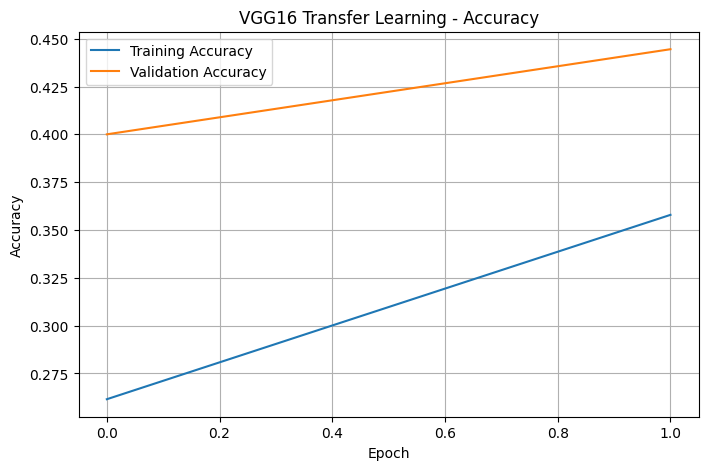

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    transfer_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    transfer_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("VGG16 Transfer Learning - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

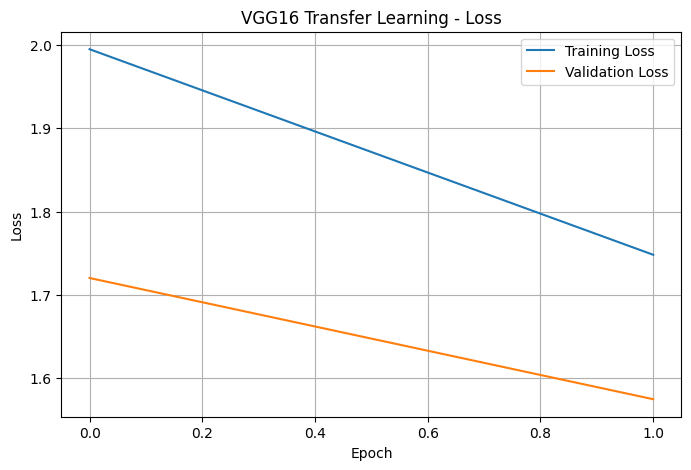

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    transfer_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    transfer_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("VGG16 Transfer Learning - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [30]:
base_vgg.trainable = True

# Freeze everything except block5
for layer in base_vgg.layers:
    if layer.name.startswith("block5"):
        layer.trainable = True
    else:
        layer.trainable = False

# Check trainable layers
for layer in base_vgg.layers:
    if layer.trainable:
        print(layer.name)

block5_conv1
block5_conv2
block5_conv3
block5_pool


In [31]:
transfer_vgg.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [32]:
import time

start_time = time.time()

fine_tune_history = transfer_vgg.fit(
    transfer_train_ds,
    validation_data=transfer_test_ds,
    epochs=5,
    verbose=1
)

fine_tuning_time = time.time() - start_time

print(
    "Fine-tuning time:",
    fine_tuning_time
)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 111s 85ms/step - accuracy: 0.4807 - loss: 1.4389 - val_accuracy: 0.6340 - val_loss: 1.0684
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 106s 85ms/step - accuracy: 0.6235 - loss: 1.0799 - val_accuracy: 0.6810 - val_loss: 0.8958
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 105s 84ms/step - accuracy: 0.6962 - loss: 0.8805 - val_accuracy: 0.6910 - val_loss: 0.9074
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 106s 84ms/step - accuracy: 0.7613 - loss: 0.7007 - val_accuracy: 0.7500 - val_loss: 0.7524
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 106s 85ms/step - accuracy: 0.8066 - loss: 0.5745 - val_accuracy: 0.7640 - val_loss: 0.7035
Fine-tuning time: 533.4254801273346


In [33]:
before_finetuning = transfer_history.history["val_accuracy"][-1]
after_finetuning = fine_tune_history.history["val_accuracy"][-1]

print(
    "Validation accuracy before fine-tuning:",
    before_finetuning
)

print(
    "Validation accuracy after fine-tuning:",
    after_finetuning
)

Validation accuracy before fine-tuning: 0.44449999928474426
Validation accuracy after fine-tuning: 0.7639999985694885


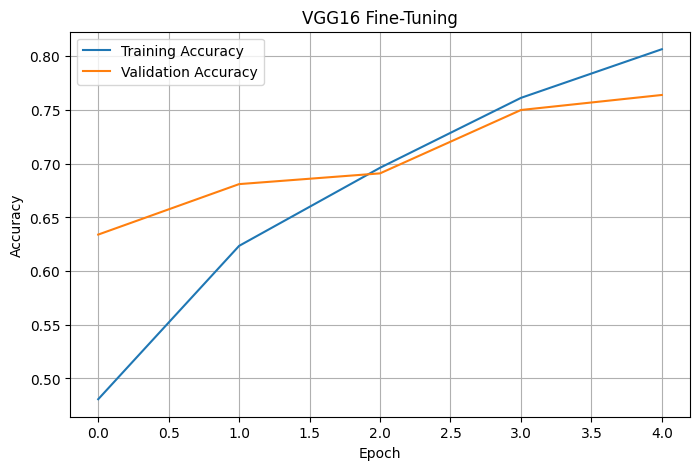

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    fine_tune_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    fine_tune_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("VGG16 Fine-Tuning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
transfer_loss, transfer_accuracy = transfer_vgg.evaluate(
    transfer_test_ds,
    verbose=0
)

transfer_predictions = transfer_vgg.predict(
    transfer_test_ds,
    verbose=0
)

transfer_pred = np.argmax(
    transfer_predictions,
    axis=1
)

transfer_precision = precision_score(
    y_test,
    transfer_pred,
    average="weighted",
    zero_division=0
)

transfer_recall = recall_score(
    y_test,
    transfer_pred,
    average="weighted",
    zero_division=0
)

transfer_f1 = f1_score(
    y_test,
    transfer_pred,
    average="weighted",
    zero_division=0
)

print("Accuracy :", transfer_accuracy)
print("Precision:", transfer_precision)
print("Recall   :", transfer_recall)
print("F1 Score :", transfer_f1)

Accuracy : 0.7639999985694885
Precision: 0.7697724810993183
Recall   : 0.764
F1 Score : 0.755193122396716


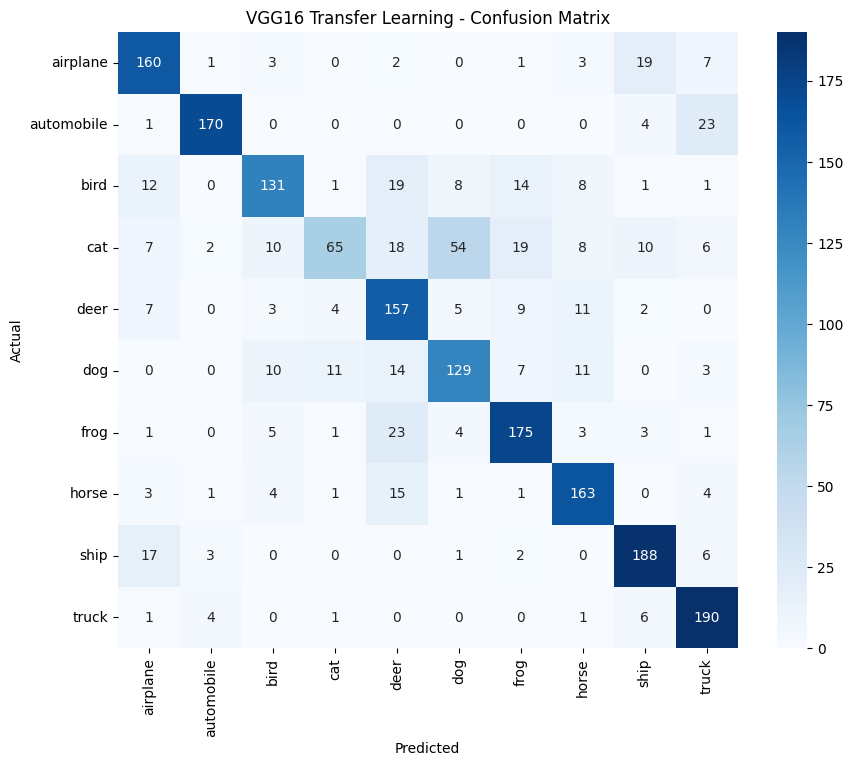

In [36]:
cm = confusion_matrix(
    y_test,
    transfer_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("VGG16 Transfer Learning - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [37]:
def build_transfer_model(
    learning_rate=0.001,
    optimizer_name="adam",
    dense_units=128,
    freeze_all=True
):

    base = keras.applications.VGG16(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3)
    )

    if freeze_all:
        base.trainable = False

    else:
        base.trainable = True

        for layer in base.layers:
            if layer.name.startswith("block5"):
                layer.trainable = True
            else:
                layer.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        dense_units,
        activation="relu"
    )(x)

    x = layers.Dropout(0.5)(x)

    output = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    model = models.Model(
        base.input,
        output
    )

    if optimizer_name == "adam":
        optimizer = keras.optimizers.Adam(
            learning_rate=learning_rate
        )
    else:
        optimizer = keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=0.9
        )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [38]:
experiments = [
    {
        "lr": 0.001,
        "optimizer": "adam",
        "dense": 128,
        "freeze": True
    },
    {
        "lr": 0.0001,
        "optimizer": "adam",
        "dense": 256,
        "freeze": True
    },
    {
        "lr": 0.0001,
        "optimizer": "sgd",
        "dense": 128,
        "freeze": False
    }
]

hyper_results = []

for i, config in enumerate(experiments):

    print("\nExperiment", i + 1)
    print(config)

    model = build_transfer_model(
        learning_rate=config["lr"],
        optimizer_name=config["optimizer"],
        dense_units=config["dense"],
        freeze_all=config["freeze"]
    )

    start = time.time()

    history = model.fit(
        transfer_train_ds,
        validation_data=transfer_test_ds,
        epochs=3 if QUICK_RUN else 10,
        verbose=1
    )

    training_time = time.time() - start

    best_val_accuracy = max(
        history.history["val_accuracy"]
    )

    hyper_results.append({
        "Learning Rate": config["lr"],
        "Optimizer": config["optimizer"],
        "Dense Units": config["dense"],
        "Frozen Base": config["freeze"],
        "Best Validation Accuracy": best_val_accuracy,
        "Training Time": training_time
    })

hyper_df = pd.DataFrame(hyper_results)

hyper_df


Experiment 1
{'lr': 0.001, 'optimizer': 'adam', 'dense': 128, 'freeze': True}
Epoch 1/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 89s 69ms/step - accuracy: 0.2619 - loss: 2.0024 - val_accuracy: 0.4060 - val_loss: 1.7178
Epoch 2/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 86s 68ms/step - accuracy: 0.3659 - loss: 1.7534 - val_accuracy: 0.4505 - val_loss: 1.5765
Epoch 3/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 85s 68ms/step - accuracy: 0.4039 - loss: 1.6483 - val_accuracy: 0.4820 - val_loss: 1.4941

Experiment 2
{'lr': 0.0001, 'optimizer': 'adam', 'dense': 256, 'freeze': True}
Epoch 1/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 89s 69ms/step - accuracy: 0.1755 - loss: 2.2414 - val_accuracy: 0.3305 - val_loss: 2.0648
Epoch 2/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 85s 68ms/step - accuracy: 0.3002 - loss: 2.0023 - val_accuracy: 0.3875 - val_loss: 1.8910
Epoch 3/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 85s 68ms/step - accuracy: 0.3460 - loss: 1.8664 - val_accuracy: 0.4280 - val_loss: 1.7755

Experiment 3
{'lr': 0.0001, 'optimizer': 'sgd', 'dense

,Learning Rate,Optimizer,Dense Units,Frozen Base,Best Validation Accuracy,Training Time
0,0.0010,adam,128,True,0.482,259.994295
1,0.0001,adam,256,True,0.428,259.600746
2,0.0001,sgd,128,False,0.508,309.403216


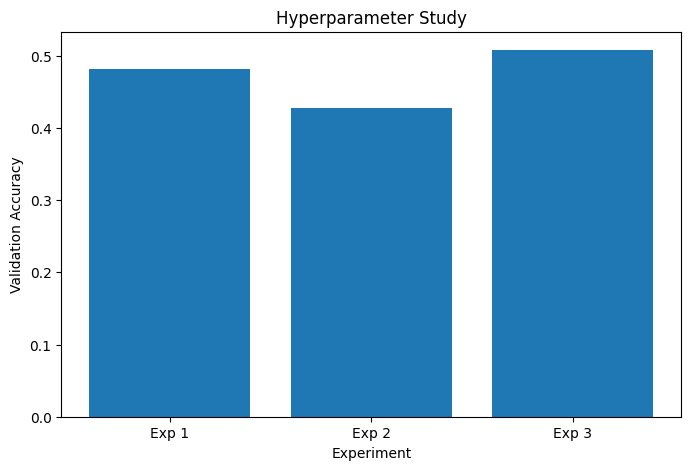

In [39]:
plt.figure(figsize=(8, 5))

plt.bar(
    range(len(hyper_df)),
    hyper_df["Best Validation Accuracy"]
)

plt.xticks(
    range(len(hyper_df)),
    [
        f"Exp {i+1}"
        for i in range(len(hyper_df))
    ]
)

plt.ylabel("Validation Accuracy")
plt.xlabel("Experiment")
plt.title("Hyperparameter Study")
plt.show()

In [40]:
final_results = results_df.copy()

final_results["Accuracy (%)"] = (
    final_results["Accuracy"] * 100
).round(2)

final_results["Precision"] = (
    final_results["Precision"] * 100
).round(2)

final_results["Recall"] = (
    final_results["Recall"] * 100
).round(2)

final_results["F1-Score"] = (
    final_results["F1-Score"] * 100
).round(2)

final_results

,Model,Accuracy,Precision,Recall,F1-Score,Parameters,Training Time (s),Accuracy (%)
0,LeNet-5,0.3825,39.00,38.25,36.46,83126,18.874114,38.25
1,AlexNet,0.4340,49.95,43.40,42.79,4484170,25.447284,43.40
2,VGG16,0.5185,52.89,51.85,50.88,3248202,19.593952,51.85
3,GoogleNet,0.4610,47.26,46.10,43.89,578210,41.793231,46.10


In [41]:
final_results.to_csv(
    "cnn_architecture_results.csv",
    index=False
)

hyper_df.to_csv(
    "hyperparameter_results.csv",
    index=False
)

print("Results saved.")

Results saved.


In [42]:
best_model = trained_models[best_model_name]

best_model.save(
    "best_cnn_model.keras"
)

print(
    "Saved:",
    best_model_name
)

Saved: VGG16
